Installing necessary libraries

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from pathlib import Path

import librosa #for audio file processing and analysis
import librosa.display #for visualizing audio data

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,  ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold,cross_val_score, cross_validate

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
#Configuration parameters
s_rate = 16000 # Sample rate in Hz
duration = 10  # seconds
N_MFCC = 30 # number of MFCC coefficients
N_FFT = 2048 # length of the FFT window
N_MELS = 128 # number of Mel bands to generate
Folds = 4
IMG_SIZE = 224


In [3]:
Device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
data_path = Path(r'D:\02_Work\04_projects\DC motor sound analysis\Dataset\BLDC_sound_data')
print('Loading the dataset')

Loading the dataset


In [5]:
# Generating the spectrogram images of the audio files and saving it for CNN model training
record = []
tar_leng = int(s_rate*duration)

print("data_path =", data_path)
print("exists:", data_path.exists())
print("is_dir:", data_path.is_dir())
print("Folders:", list(data_path.iterdir()))

out_dir = Path(r'D:\02_Work\04_projects\DC motor sound analysis\Dataset\BLDC_spectrogram_images')
out_dir.mkdir(exist_ok=True)


for class_dir in sorted(data_path.iterdir()):
  if not class_dir.is_dir():
        continue
  raw_label = class_dir.name

  img_cls = out_dir /raw_label
  img_cls.mkdir(exist_ok=True)

  for subdir in sorted(class_dir.iterdir()):
    motor_id = subdir.name

    # checking the sub meta folder for the audio files

    for audio_file in sorted(subdir.glob('*.wav')):
        out_path = img_cls / f"{raw_label}_{motor_id}_{audio_file.stem}.png"
        y,_ = librosa.load(audio_file, sr=s_rate, duration = duration)
    
        # if in case the audio file is shorter than the expected duration, we are doing padding for the remaing part of the audio
        if len(y)<tar_leng:
            y = np.pad(y, (0, tar_leng - len(y)), mode='constant')
        else:
            y = y[:tar_leng]
            y = np.array(y, dtype=np.float32)
        s = librosa.feature.melspectrogram(y=y, sr=s_rate, n_fft=N_FFT, n_mels=N_MELS)
        s_db = librosa.power_to_db(s, ref=np.max)

        # normalizing 
        s_db_norm = (s_db - s_db.min()) / (s_db.max() - s_db.min())

        # converting it into 3 channel image by stacking the spectrogram 3 times
        img_arr = (s_db_norm*255).astype(np.uint8)
        img = Image.fromarray(img_arr).convert('RGB')
        img.save(out_path)

        record.append((out_path, raw_label))
print('The audio files has been saved as spectrogram image')



data_path = D:\02_Work\04_projects\DC motor sound analysis\Dataset\BLDC_sound_data
exists: True
is_dir: True
Folders: [WindowsPath('D:/02_Work/04_projects/DC motor sound analysis/Dataset/BLDC_sound_data/Bearing'), WindowsPath('D:/02_Work/04_projects/DC motor sound analysis/Dataset/BLDC_sound_data/Healthy'), WindowsPath('D:/02_Work/04_projects/DC motor sound analysis/Dataset/BLDC_sound_data/Propeller')]
The audio files has been saved as spectrogram image


In [6]:
# Class for creating spectrogram image dataset for CNN model training
class SpectrogramDataset(Dataset):
  def __init__(self, record, label_encoder, transform = None):
    self.record = record
    self.label_encoder = label_encoder
    self.transform = transform

  def __len__(self):
    return len(self.record)

  def __getitem__(self, idx):
    img_path, label = self.record[idx]
    image = Image.open(img_path).convert('RGB')
    if self.transform:
      image = self.transform(image)
    label_encoded = self.label_encoder.transform([label])[0]
    return image, label_encoded 

In [7]:
from torch.utils.data import WeightedRandomSampler

labels = [r[1] for r in record]
unique = set(labels)
unique = sorted(unique)
print(unique)

le = LabelEncoder()
labels = le.fit_transform(labels)
num_classes = len(le.classes_)
print("num_classes =", num_classes)

['Bearing', 'Healthy', 'Propeller']
num_classes = 3


In [8]:
# Since we have small dataset we have to do data augmentation to increase the size of the dataset to prevent overfitting
from torchvision import transforms
train_transform = transforms.Compose([
  transforms.Resize((IMG_SIZE, IMG_SIZE)),
  transforms.RandomHorizontalFlip(),
  transforms.RandomRotation(10),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
  transforms.Resize((IMG_SIZE, IMG_SIZE)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [9]:
# DNN model architectures
from torchvision import models

def build_model(num_classes: int, pretrained: bool =True) -> nn.Module:
  model = models.resnet18(weights = "IMAGENET1K_V1", pretrained=pretrained)
  in_features = model.fc.in_features
  model.fc = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, num_classes)
  )
  return model

class my_CNN(nn.Module):
  def __init__(self, num_classes):
    super(my_CNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
    self.fc1 = nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 256)
    self.fc2 = nn.Linear(256, num_classes)

  def forward(self, x):
    x =self.conv1(x)
    x =F.relu(x)
    x =self.pool(x)
    x =self.conv2(x)
    x =F.relu(x)
    x =self.pool(x)
    x =self.conv3(x)
    x =F.relu(x)
    x =self.pool(x)
    x =x.view(x.size(0), -1)
    x =self.fc1(x)
    x =F.relu(x)
    x =self.fc2(x)
    return x
  

In [10]:
# Cross validation and training in addition to early stopping to prevent overfitting
from collections import Counter

patience = 10
delta = 0.001

USE_PRETRAINED = False
records_np = np.array(record, dtype=object)

cv = StratifiedKFold(n_splits = Folds, shuffle = True, random_state =42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(cv.split(records_np, labels)):
  print(f"Fold {fold+1}/{Folds}")

  best_val_loss = float('inf')
  no_improve = 0 

  train_records = records_np[train_idx].tolist()
  val_records   = records_np[val_idx].tolist()

  # creating the dataset and dataloader for training and validation
  train_dataset = SpectrogramDataset(train_records, le, transform=train_transform)
  val_dataset = SpectrogramDataset(val_records, le, transform=val_transform)

  train_labels = [le.transform([r[1]])[0] for r in train_records]
  counts = Counter(train_labels)
  weights = [1.0 / counts[l] for l in train_labels]
  sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

  # using weighted random sampler for handling class imbalance in dataset
  train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
  val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

  if USE_PRETRAINED:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
  else:
    model = my_CNN(num_classes=num_classes)

  model = model.to(Device)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=0.001)
  num_epochs = 100

  best_val_acc = 0.0

  for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
      images, labels = images.to(Device), labels.to(Device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
      for images, labels in val_loader:
        images, labels = images.to(Device), labels.to(Device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_acc = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_acc:.4f}")  

    if val_epoch_loss < best_val_loss - delta:
      best_val_loss = val_epoch_loss
      no_improve = 0
    else:
      no_improve += 1

    if no_improve >= patience:
      print(f"Early stopping at epoch {epoch+1}")
      break
  fold_accuracies.append(val_acc)
  print(f"Fold {fold+1} best accuracy: {val_acc:.4f}")
print("Fold Accuracies:", fold_accuracies)
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f}")


Fold 1/4
Epoch 1/100, Loss: 1.0987, Val Loss: 2.8538, Val Acc: 0.1818
Epoch 2/100, Loss: 2.3456, Val Loss: 1.0718, Val Acc: 0.5455
Epoch 3/100, Loss: 1.4365, Val Loss: 1.0825, Val Acc: 0.2727
Epoch 4/100, Loss: 1.1267, Val Loss: 1.0963, Val Acc: 0.2727
Epoch 5/100, Loss: 1.1414, Val Loss: 1.0819, Val Acc: 0.2727
Epoch 6/100, Loss: 1.0952, Val Loss: 1.0813, Val Acc: 0.2727
Epoch 7/100, Loss: 1.0793, Val Loss: 1.0839, Val Acc: 0.2727
Epoch 8/100, Loss: 1.0739, Val Loss: 1.0697, Val Acc: 0.2727
Epoch 9/100, Loss: 1.0200, Val Loss: 1.0705, Val Acc: 0.2727
Epoch 10/100, Loss: 1.0290, Val Loss: 1.0804, Val Acc: 0.2727
Epoch 11/100, Loss: 1.0404, Val Loss: 0.9887, Val Acc: 0.3636
Epoch 12/100, Loss: 0.9240, Val Loss: 0.9186, Val Acc: 0.7273
Epoch 13/100, Loss: 0.9396, Val Loss: 0.8876, Val Acc: 0.9091
Epoch 14/100, Loss: 0.8412, Val Loss: 0.8248, Val Acc: 0.9091
Epoch 15/100, Loss: 0.7525, Val Loss: 0.7362, Val Acc: 0.8182
Epoch 16/100, Loss: 0.6216, Val Loss: 0.6847, Val Acc: 0.8182
Epoch 17

In [11]:
labels = np.array([le.transform([r[1]])[0] for r in record])

train_records, temp_records, train_labels, temp_labels = train_test_split(record,labels,test_size=0.30,stratify=labels,random_state=42)
val_records, test_records, val_labels, test_labels = train_test_split(temp_records,temp_labels,test_size=0.3333,stratify=temp_labels,random_state=42)

train_dataset = SpectrogramDataset(train_records, le, transform=train_transform)
val_dataset = SpectrogramDataset(val_records, le, transform=val_transform)
test_dataset = SpectrogramDataset(test_records, le, transform=val_transform)

train_labels = [le.transform([r[1]])[0] for r in train_records]
counts = Counter(train_labels)
weights = [1.0 / counts[l] for l in train_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

if USE_PRETRAINED:
  model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
else:
  model = my_CNN(num_classes=num_classes)

model = model.to(Device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 40
best_val_acc = 0.0
best_val_loss = float('inf')
no_improve = 0 

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0

  for images, labels in train_loader:
    images, labels = images.to(Device), labels.to(Device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * images.size(0)
  epoch_loss = running_loss / len(train_loader.dataset)

  model.eval()
  val_running_loss = 0.0
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(Device), labels.to(Device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      val_running_loss += loss.item() * images.size(0)
      _, preds = torch.max(outputs, 1)
      all_preds.extend(preds.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())
  
  val_epoch_loss = val_running_loss / len(val_loader.dataset)
  val_acc = accuracy_score(all_labels, all_preds)
  print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_acc:.4f}")  

  if val_epoch_loss < best_val_loss - delta:
    best_val_loss = val_epoch_loss
    no_improve = 0
  else:
    no_improve += 1

  if no_improve >= patience:
    print(f"Early stopping at epoch {epoch+1}")
    break


Epoch 1/40, Loss: 1.0987, Val Loss: 5.5437, Val Acc: 0.3750
Epoch 2/40, Loss: 3.1609, Val Loss: 2.6062, Val Acc: 0.1250
Epoch 3/40, Loss: 2.1446, Val Loss: 0.9209, Val Acc: 0.5000
Epoch 4/40, Loss: 1.0199, Val Loss: 0.9266, Val Acc: 0.5000
Epoch 5/40, Loss: 1.0675, Val Loss: 0.9229, Val Acc: 0.7500
Epoch 6/40, Loss: 1.0818, Val Loss: 0.9328, Val Acc: 0.6250
Epoch 7/40, Loss: 0.8832, Val Loss: 0.9924, Val Acc: 0.7500
Epoch 8/40, Loss: 0.7827, Val Loss: 1.1750, Val Acc: 0.3750
Epoch 9/40, Loss: 0.7521, Val Loss: 1.1968, Val Acc: 0.3750
Epoch 10/40, Loss: 0.8745, Val Loss: 0.9705, Val Acc: 0.5000
Epoch 11/40, Loss: 0.4610, Val Loss: 0.8258, Val Acc: 0.5000
Epoch 12/40, Loss: 0.4638, Val Loss: 0.7710, Val Acc: 0.5000
Epoch 13/40, Loss: 0.5280, Val Loss: 0.6681, Val Acc: 0.6250
Epoch 14/40, Loss: 0.5706, Val Loss: 0.5836, Val Acc: 0.6250
Epoch 15/40, Loss: 0.3919, Val Loss: 0.5680, Val Acc: 0.7500
Epoch 16/40, Loss: 0.3118, Val Loss: 0.5740, Val Acc: 0.8750
Epoch 17/40, Loss: 0.5138, Val Lo

Classification Report:
              precision    recall  f1-score   support

     Bearing       0.00      0.00      0.00         1
     Healthy       0.67      0.67      0.67         3
   Propeller       0.50      1.00      0.67         1

    accuracy                           0.60         5
   macro avg       0.39      0.56      0.44         5
weighted avg       0.50      0.60      0.53         5

Test Accuracy: 0.6


c:\Users\Guru Prasaath P\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guru Prasaath P\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guru Prasaath P\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

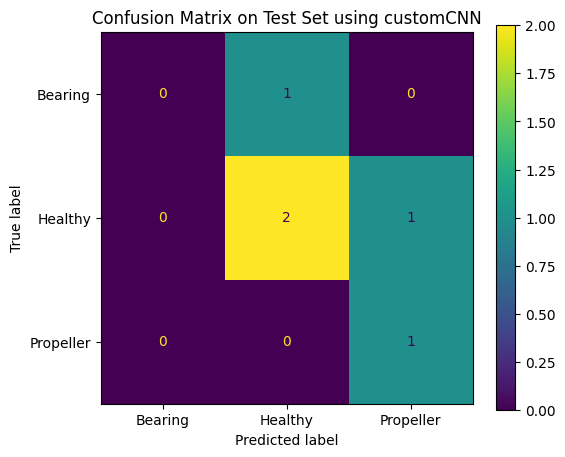

In [12]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(Device), labels.to(Device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))
print("Test Accuracy:", accuracy_score(all_labels, all_preds))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix on Test Set using customCNN")
plt.show()